In [1]:
# Cell 1: Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
# Cell 2: Đọc dữ liệu sạch
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

print("Kích thước dữ liệu:", df.shape)
display(df.head())

Kích thước dữ liệu: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Cell 3: Mã hóa biến mục tiêu
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print(df["Churn"].value_counts())
display(df.head())

Churn
0    5163
1    1869
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
# Cell 4: Tách X và y
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Kích thước X: (7032, 19)
Kích thước y: (7032,)


In [5]:
# Cell 5: Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 19)
X_test : (1407, 19)
y_train: (5625,)
y_test : (1407,)


In [6]:
# Cell 6: Xác định nhóm biến
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = [col for col in X.columns if col not in numerical_features]

print("Biến số:", numerical_features)
print("Biến phân loại:", categorical_features)

Biến số: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Biến phân loại: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [7]:
# Cell 7: Preprocessor cho Gaussian Naive Bayes
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [8]:
# Cell 8: Tiền xử lý dữ liệu
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# GaussianNB cần dense array
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)

X_train_processed shape: (5625, 30)
X_test_processed shape : (1407, 30)


In [9]:
# Cell 9: Huấn luyện Gaussian Naive Bayes
gnb_model = GaussianNB()
gnb_model.fit(X_train_processed, y_train)

print("Huấn luyện Gaussian Naive Bayes thành công.")

Huấn luyện Gaussian Naive Bayes thành công.


In [10]:
# Cell 10: Dự đoán trên tập test
y_pred = gnb_model.predict(X_test_processed)
y_prob = gnb_model.predict_proba(X_test_processed)[:, 1]

print("Dự đoán xong.")

Dự đoán xong.


In [11]:
# Cell 11: Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=== Gaussian Naive Bayes ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

=== Gaussian Naive Bayes ===
Accuracy : 0.6446
Precision: 0.4184
Recall   : 0.8636
F1-score : 0.5637
ROC-AUC  : 0.8102


In [12]:
# Cell 12: Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.57      0.70      1033
           1       0.42      0.86      0.56       374

    accuracy                           0.64      1407
   macro avg       0.67      0.71      0.63      1407
weighted avg       0.79      0.64      0.66      1407



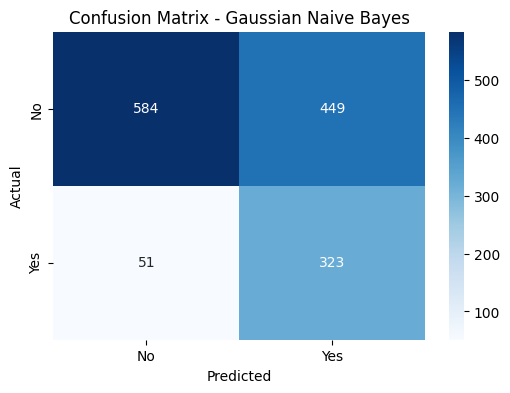

In [13]:
# Cell 13: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"],
            yticklabels=["No", "Yes"])
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

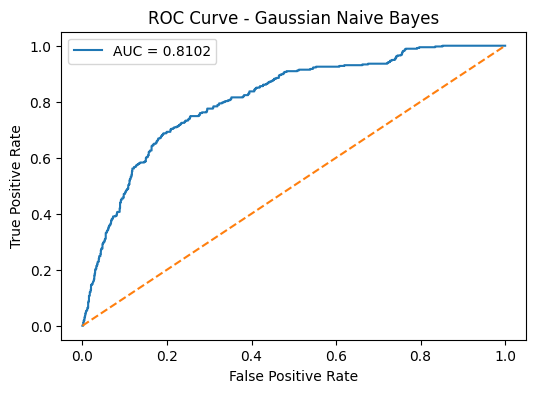

In [14]:
# Cell 14: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gaussian Naive Bayes")
plt.legend()
plt.show()

In [15]:
# Cell 15: Xem prior của mô hình
print("Class prior probabilities:", gnb_model.class_prior_)
print("Classes:", gnb_model.classes_)

Class prior probabilities: [0.73422222 0.26577778]
Classes: [0 1]


In [16]:
# Cell 16: Lưu kết quả metric
nb_results = pd.DataFrame({
    "Model": ["Gaussian Naive Bayes"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "ROC-AUC": [roc_auc]
})

display(nb_results)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gaussian Naive Bayes,0.644634,0.418394,0.863636,0.5637,0.810182
